### 03. LangChain + LangGraph + MySQL + MCP Streamable HTTP

```text
Jupyter Notebook
      ↓
HTTP
      ↓
MCP Client
      ↓
http://127.0.0.1:8000/mcp
      ↓
MCP Server
      ↓
MySQL
```


## 학습 목표

1. Streamable HTTP 개념
2. MCP HTTP Server 실행
3. `MultiServerMCPClient` HTTP 연결
4. MCP Tool 직접 호출
5. LangChain Agent + MCP
6. LangGraph ToolNode + MCP
7. RAG Subgraph + MCP(MySQL) Hybrid Graph


### Part 1. MCP 사용해보기

### 1. 환경 설치

새 Conda 환경을 권장합니다.

```bash
conda create -n langchain_up python=3.12 -y
conda activate langchain_up

pip install -r requirements_latest.txt
```

설치 후 Jupyter Kernel을 재시작합니다.


### 2. MCP HTTP Server 먼저 실행

**중요:** 서버는 Notebook 셀에서 실행하지 않습니다.
Anaconda Prompt 또는 VS Code Terminal을 하나 별도로 열고 실행합니다.
```bash
python student_mysql_mcp_http_server.py
```

정상 실행되면 MCP Endpoint는:
```text
http://127.0.0.1:8000/mcp
```
입니다.

이 Terminal은 서버를 계속 실행한 상태로 둡니다.


### 3. Import

실행 중인 MCP HTTP Server에 접속합니다.


In [1]:
import json

from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_mcp_adapters.client import MultiServerMCPClient

from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

from IPython.display import Image, display

import warnings
warnings.filterwarnings("ignore")

In [2]:
load_dotenv()

True

### 4. LLM 생성

In [3]:
llm = ChatOpenAI(model="gpt-4o-mini")

### 5. Streamable HTTP MCP Client 생성

LangChain MCP Adapter에서는 Streamable HTTP Server에 대해 `transport="http"`를 사용할 수 있습니다.

서버 URL:

```text
http://127.0.0.1:8000/mcp
```


In [4]:
# ============================================================
# MCP Client
# ============================================================

mcp_client = MultiServerMCPClient(
    {
        "student_mysql": {
            "transport": "http", # Streamable HTTP
            "url":"http://127.0.0.1:8000/mcp", # 별도로 실행 중인 MCP Server
        }
    }
)

### 6. MCP Tool 가져오기

`get_tools()`는 MCP Server가 제공하는 Tool을 읽어와 LangChain Tool 형태로 변환합니다.


In [5]:
# MCP Tool Load
mcp_tools = await mcp_client.get_tools()

print("Tool 개수:", len(mcp_tools))

for tool in mcp_tools:
    print("Tool 이름:", tool.name)
    print("설명:", tool.description)
    print( "-" * 50)


Tool 개수: 2
Tool 이름: search_student
설명: 
    학생 이름으로 MySQL students 테이블에서
    학생 정보를 조회합니다.
    
--------------------------------------------------
Tool 이름: list_students
설명: 
    MySQL students 테이블의 전체 학생 목록을 조회합니다.
    
--------------------------------------------------


정상이라면 다음 Tool이 표시됩니다.

```text
search_student
list_students
```


### 7. MCP Tool 직접 실행

먼저 LLM 없이 MCP Tool만 직접 호출합니다.

이 단계가 정상이어야 이후 Agent도 정상 동작합니다.


In [6]:
tool_map = {tool.name: tool for tool in mcp_tools}

result = await tool_map["search_student"].ainvoke(
    {
        "name": "이순신"
    }
)

print(result)

[{'type': 'text', 'text': '[{"id": 3, "name": "이순신", "age": 48, "course": "LangChain"}, {"id": 4, "name": "이순신", "age": 48, "course": "LangChain"}]', 'id': 'lc_fb19a15d-a4a0-499f-a20f-7e42a9179841'}]


실행 흐름:

```text
Notebook
   ↓
MCP Client
   ↓ HTTP
MCP Server
   ↓
search_student()
   ↓
MySQL
   ↓
결과 반환
```


### Part 2. LangChain Agent + MCP

MCP Server에서 가져온 Tool은 일반 LangChain Tool처럼 Agent에 전달할 수 있습니다.


In [10]:
# LangChain MCP Agent

mcp_agent = create_agent(model=llm, tools=mcp_tools, )

In [11]:
# 자연어 질문
response = await mcp_agent.ainvoke(
    {
        "messages": [
            {
                "role":"user",
                "content": "이순신 학생의 수강과목을 알려주세요."
            }
        ]
    }
)


print(response["messages"][-1].content)


이순신 학생은 "LangChain" 과목을 수강하고 있습니다.


실행 흐름:

```text
사용자
   ↓
LangChain Agent
   ↓
Tool 필요 판단
   ↓
search_student
   ↓
MCP Client
   ↓ HTTP
MCP Server
   ↓
MySQL
   ↓
Agent
   ↓
최종 답변
```


### Part 3. LangGraph + MCP ToolNode

이번에는 `create_agent()` 내부 동작을 LangGraph로 직접 구성합니다.


In [ ]:
# LLM + MCP Tools
llm_with_mcp_tools = llm.bind_tools(mcp_tools)

def call_model(state: MessagesState):
    """
    사용자의 메시지를 LLM에 전달합니다.

    LLM은 질문에 따라
    MCP Tool 사용 여부를 판단합니다.
    """

    response = llm_with_mcp_tools.invoke(state["messages"])

    return {"messages": [response]}


# ToolNode
# MCP Tool 역시 LangChain Tool 형태이므로 ToolNode에 그대로 전달 가능

mcp_tool_node = ToolNode(mcp_tools)


In [13]:
# LangGraph 구성

mcp_graph_builder = StateGraph(MessagesState)

mcp_graph_builder.add_node("call_model", call_model)
mcp_graph_builder.add_node("tools", mcp_tool_node)

mcp_graph_builder.add_edge(START, "call_model")

mcp_graph_builder.add_conditional_edges(
    "call_model",
    tools_condition,
)

# Tool 실행 후 다시 LLM에게 결과 전달
mcp_graph_builder.add_edge("tools", "call_model")

mcp_graph = mcp_graph_builder.compile()

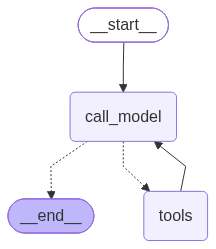

In [14]:
display(Image(mcp_graph.get_graph().draw_mermaid_png()))

In [15]:
mcp_graph_result = await mcp_graph.ainvoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "이순신 학생 정보를 조회해주세요."
            }
        ]
    }
)


print(mcp_graph_result["messages"][-1].content)


이순신 학생의 정보는 다음과 같습니다:

- **ID**: 3
- **이름**: 이순신
- **나이**: 48
- **수업**: LangChain


### Part 4. RAG Subgraph 구성

기존 Hybrid 수업에서 사용한 RAG는 독립 Subgraph로 유지합니다.


In [17]:
embeddings = OllamaEmbeddings(model="bge-m3")


policy_db = Chroma(
    persist_directory="./chroma_db",
    embedding_function=embeddings,
    collection_name="school_policy",
)

policy_retriever = policy_db.as_retriever(
    search_kwargs={"k": 2}
)



In [18]:
# RAG State
class RAGState(TypedDict, total=False,):
    question: str
    documents: list[Document]
    rag_answer: str


# Retrieve Node
def retrieve_policy(state: RAGState) -> RAGState:
    print("---RAG: retrieve---")

    docs = policy_retriever.invoke(state["question"])

    return {"documents": docs}


# Generate Node

def generate_rag_answer(state: RAGState) -> RAGState:
    print("---RAG: generate---")

    context = "\n\n".join(
        (
            f"[출처: "
            f"{doc.metadata.get('source', '')}]\n"
            f"{doc.page_content}"
        ) for doc in state.get("documents", [])
    )

    prompt = f"""
당신은 학사규정 안내 AI입니다.

아래 검색 문서만 근거로 질문에 답변하세요.
검색 문서에 없는 내용은 임의로 만들지 마세요.

[질문]
{state["question"]}

[검색 문서]
{context}
"""

    response = llm.invoke(prompt)

    return {"rag_answer":  response.content}


In [19]:
# RAG Subgraph

rag_builder = StateGraph(RAGState)

rag_builder.add_node("retrieve", retrieve_policy)
rag_builder.add_node("generate", generate_rag_answer)

rag_builder.add_edge(START, "retrieve")
rag_builder.add_edge("retrieve", "generate")
rag_builder.add_edge("generate", END)

rag_graph = rag_builder.compile()

### Part 5. RAG + MCP(MySQL) Hybrid Graph

이제 기존 MySQL Node를 MCP HTTP 호출 Node로 교체합니다.

```text
                     사용자
                        ↓
                   Hybrid Router
                  ↙             ↘
           RAG Subgraph      MCP MySQL
               ↓                 ↓
           Vector DB        MCP Client
                                ↓ HTTP
                            MCP Server
                                ↓
                              MySQL
                  ↘             ↙
                     Answer
                       ↓
                      END
```


In [20]:
# Hybrid State

class HybridState(TypedDict, total=False,):
    question: str 
    datasource: str     # rag / mcp_mysql
    context: str    # 검색 결과
    final_answer: str


# Router Structured Output
class HybridRoute(BaseModel):
    datasource: Literal["rag", "mcp_mysql",] = Field(
        description=("학교 규정, 정책, 기준, 제한, 절차, "
                     "최대 학점, 출석 규정 질문이면 rag. "
                     "특정 학생 개인의 이름, 나이, "
                     "수강과목 정보를 묻는 질문이면 mcp_mysql."
                )
    )


hybrid_router_llm = llm.with_structured_output(HybridRoute, method="json_schema",)


In [21]:
# Hybrid Router
def analyze_hybrid_question(state: HybridState) -> HybridState:

    print("---Hybrid Router---")

    router_prompt = f"""
당신은 학사관리 Hybrid Router입니다.

반드시 다음 중 하나를 선택하세요.

- rag
- mcp_mysql

[RAG]

학교 전체 규정, 정책, 기준, 제한,
절차에 대한 질문입니다.

예:
- 한 학기에 최대 몇 학점까지 수강할 수 있나요?
- 출석률 기준은 무엇인가요?
- 수강신청 변경 기간은 언제까지인가요?


[MCP_MYSQL]

특정 학생 개인의 현재 정보를
조회하는 질문입니다.

예:
- 이순신 학생의 수강과목은 무엇인가요?
- 홍길동 학생의 나이는 몇 살인가요?


중요:
'수강'이라는 단어만으로
mcp_mysql을 선택하지 마세요.

특정 학생 개인을 조회하는 경우에만
mcp_mysql을 선택합니다.


[사용자 질문]

{state["question"]}
"""
    result = hybrid_router_llm.invoke(router_prompt)


    print("선택:", result.datasource)

    return {"datasource": result.datasource}


def route_hybrid(state: HybridState) -> Literal["rag","mcp_mysql",]:
    return state["datasource"]


In [22]:
# Hybrid RAG Node

def hybrid_rag_node(state: HybridState) -> HybridState:

    print("---Hybrid: RAG Subgraph---")

    result = rag_graph.invoke(
        {
            "question": state["question"]
        }
    )


    return {"context": 
            result.get("rag_answer",
                        "관련 규정을 찾을 수 없습니다."
            )
    }


# 학생 이름 추출
class StudentName(BaseModel):

    name: str = Field(
        description="질문에 등장하는 특정 학생 이름"
    )


student_name_llm = llm.with_structured_output(StudentName,
                                              method="json_schema",)


# Hybrid MCP MySQL Node
async def hybrid_mcp_mysql_node(state: HybridState) -> HybridState:

    print("---Hybrid: MCP HTTP → MySQL---")

    # 사용자 질문에서 학생 이름 추출
    parsed = student_name_llm.invoke(state["question"])


    # MCP Server의 search_student Tool 호출
    result = await tool_map["search_student"].ainvoke(
        {
            "name": parsed.name
        }
    )


    return {"context": result}


In [25]:
# Hybrid Answer Node
def hybrid_answer_node(state: HybridState) -> HybridState:

    print("---Hybrid: Answer---")

    prompt = f"""
당신은 학사관리 AI Assistant입니다.

아래 검색 결과만 근거로 답변하세요.

검색 결과에 없는 정보는
임의로 만들지 마세요.

[질문]
{state["question"]}

[검색 결과]
{state.get("context", "")}
"""

    response = llm.invoke(prompt)

    return {"final_answer": response.content}


In [26]:
# Hybrid Graph

hybrid_builder = StateGraph(HybridState)

hybrid_builder.add_node("analyze", analyze_hybrid_question)
hybrid_builder.add_node("rag", hybrid_rag_node)
hybrid_builder.add_node("mcp_mysql", hybrid_mcp_mysql_node)
hybrid_builder.add_node("answer", hybrid_answer_node)

hybrid_builder.add_edge(START, "analyze")

hybrid_builder.add_conditional_edges(
    "analyze",
    route_hybrid,
    {
        "rag": "rag",
        "mcp_mysql": "mcp_mysql",
    }
)

hybrid_builder.add_edge("rag", "answer")
hybrid_builder.add_edge("mcp_mysql", "answer")
hybrid_builder.add_edge("answer", END)

hybrid_mcp_graph = hybrid_builder.compile()

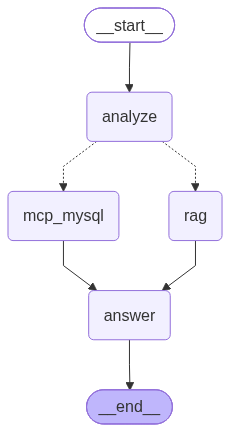

In [27]:
display(Image(hybrid_mcp_graph.get_graph().draw_mermaid_png()))

### RAG 경로 테스트

In [28]:
rag_test = (
    await hybrid_mcp_graph.ainvoke(
        {
            "question": "한 학기에 최대 몇 학점까지 수강할 수 있나요?"
        }
    )
)


print("선택:", rag_test.get("datasource"))
print("\n답변:")
print(rag_test.get("final_answer"))


---Hybrid Router---
선택: rag
---Hybrid: RAG Subgraph---
---RAG: retrieve---
---RAG: generate---
---Hybrid: Answer---
선택: rag

답변:
한 학기에 최대 몇 학점까지 수강할 수 있는지에 대한 정보는 검색 결과에 없습니다. 정확한 정보를 원하시면 관련 규정을 확인하시기 바랍니다.


정상적인 선택:

```text
rag
```


### MCP MySQL 경로 테스트

In [ ]:
mysql_test = (
    await hybrid_mcp_graph.ainvoke(
        {
            "question": "이순신 학생의 수강과목을 알려주세요."
        }
    )
)


print("선택:", mysql_test.get("datasource"))
print("\n답변:")
print(mysql_test.get("final_answer"))


정상적인 선택:

```text
mcp_mysql
```


# Part 6. 서버와 Client 역할 정리

### MCP Server

```text
student_mysql_mcp_http_server.py
          ↓
FastMCP
          ↓
search_student / list_students
          ↓
MySQL
```

### MCP Client

```text
Jupyter Notebook
       ↓
MultiServerMCPClient
       ↓
HTTP
       ↓
http://127.0.0.1:8000/mcp
```

### 전체 Hybrid

```text
사용자
   ↓
Hybrid Router
 ↙           ↘
RAG         MCP
 ↓           ↓
Chroma      HTTP
             ↓
         MCP Server
             ↓
           MySQL
 ↘           ↙
    Answer
      ↓
     END
```


# Part 7. 실행 순서

수업에서는 반드시 다음 순서를 권장합니다.

```text
1. MySQL Server 실행
        ↓
2. students 테이블 확인
        ↓
3. Ollama 실행
        ↓
4. ollama pull bge-m3
        ↓
5. MCP HTTP Server 실행
   python student_mysql_mcp_http_server.py
        ↓
6. Jupyter Notebook 실행
        ↓
7. MCP Tool Load 확인
        ↓
8. MCP Tool 직접 호출
        ↓
9. LangChain Agent + MCP
        ↓
10. LangGraph ToolNode + MCP
        ↓
11. RAG + MCP(MySQL) Hybrid Graph
```
